# Predicting Antibacterial Activity Against E. coli Using Molecular Descriptors

### Priscilla Vaskez · Trinity Ho · Yasemin Sucu · Dongwan Kim

## Objective

Predict the antibacterial inhibition rate against E. coli (INHIB_AVE) using a combination of molecular descriptors computed from small-molecule SMILES data (for example: molecular weight, logP, TPSA) and experimental features extracted directly from the CO-ADD dataset (for example: INHIB_STD, NASSAYS, DMAX_AVE, MIC-derived features). Our models learn to predict the continuous inhibition percentage directly from these features. We train and compare three classical ML regression models.

# Basic Data Preview

Read CO-ADD CSV files with pandas and preview the first rows using `head()`.

CO-ADD provides two CSV files because they serve different purposes:
- `InhibitionData` contains single-concentration inhibition results (good for quick screening).
- `DoseResponseData` contains multi-concentration dose-response results (better for detailed potency analysis).

In [74]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import pylab
import scipy.stats as stats
import statsmodels.api as sm
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, QED, rdMolDescriptors
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from statsmodels.formula.api import ols
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from pyclustering.utils.metric import * 
import umap
from nltk.cluster.kmeans import KMeansClusterer   
from scipy.optimize import linear_sum_assignment

---
This sets the folder and file paths for the two CO-ADD CSV files.
- `DATA_DIR` points to the folder containing the data.
- `INHIB_PATH` and `DOSE_PATH` build the full path to each CSV file using `Path` / operator.

In [2]:
DATA_DIR = Path("CO-ADD_r03.02-2020_CSV")
INHIB_PATH = DATA_DIR / "CO-ADD_InhibitionData_r03_01-02-2020_CSV.csv"
DOSE_PATH = DATA_DIR / "CO-ADD_DoseResponseData_r03_01-02-2020_CSV.csv"

---

## Open Inhibition data CSV file

In [3]:
# There are two CSV files in the CO-ADD folder.
# For now, we will open the InhibitionData file.

df = pd.read_csv(INHIB_PATH, low_memory=False)
print(df.head())

   Unnamed: 0        COADD_ID  COMPOUND_CODE COMPOUND_NAME     PROJECT_ID  \
0           0  CO-ADD:0227954  A0879/0041231           NaN  CO-ADD:PC0244   
1           1  CO-ADD:0227954  A0879/0041231           NaN  CO-ADD:PC0244   
2           2  CO-ADD:0227954  A0879/0041231           NaN  CO-ADD:PC0244   
3           3  CO-ADD:0227808  A0856/0040122           NaN  CO-ADD:PC0244   
4           4  CO-ADD:0227808  A0856/0040122           NaN  CO-ADD:PC0244   

                          LIBRARY_NAME ASSAY_ID                 ORGANISM  \
0  Russian Academy of Science (Russia)   GN_046         Escherichia coli   
1  Russian Academy of Science (Russia)   GN_049         Escherichia coli   
2  Russian Academy of Science (Russia)   GP_020    Staphylococcus aureus   
3  Russian Academy of Science (Russia)   FG_001         Candida albicans   
4  Russian Academy of Science (Russia)   FG_002  Cryptococcus neoformans   

             STRAIN  NASSAYS  INHIB_AVE  INHIB_STD      CONC  \
0      lpxC; MB4

---
## Open the other CO-ADD file (DoseResponseData)

In [4]:
# Open the other CO-ADD file (DoseResponseData)
df2 = pd.read_csv(DOSE_PATH, low_memory=False)
print(df2.head())

   Unnamed: 0        COADD_ID COMPOUND_CODE COMPOUND_NAME  \
0           0  CO-ADD:0136135    0367428:01           NaN   
1           1  CO-ADD:0136135    0367428:01           NaN   
2           2  CO-ADD:0136135    0367428:01           NaN   
3           3  CO-ADD:0136135    0367428:01           NaN   
4           4  CO-ADD:0136135    0367428:01           NaN   

                                   SMILES     PROJECT_ID  \
0  [H]N1C(N([H])C(OC)C(C(OC)=O)(F)C1=O)=O  CO-ADD:PL0011   
1  [H]N1C(N([H])C(OC)C(C(OC)=O)(F)C1=O)=O  CO-ADD:PL0011   
2  [H]N1C(N([H])C(OC)C(C(OC)=O)(F)C1=O)=O  CO-ADD:PL0011   
3  [H]N1C(N([H])C(OC)C(C(OC)=O)(F)C1=O)=O  CO-ADD:PL0011   
4  [H]N1C(N([H])C(OC)C(C(OC)=O)(F)C1=O)=O  CO-ADD:PL0011   

                      LIBRARY_NAME ASSAY_ID                 ORGANISM  \
0  NIH/NCI (USA) - Diversity Set V   MA_007             Homo sapiens   
1  NIH/NCI (USA) - Diversity Set V   GP_020    Staphylococcus aureus   
2  NIH/NCI (USA) - Diversity Set V   GN_042   Pseudomona

---
The below cell reads the two CO-ADD CSV files into pandas DataFrames and prints basic information about them.
- `shape` shows the number of rows and columns in each file.
- `columns.tolist()` lists the column names so you can see what data fields are available.
This helps verify the files loaded correctly and shows what information each dataset contains.

In [5]:
df_inhib = pd.read_csv(INHIB_PATH, low_memory=False)
df_dose = pd.read_csv(DOSE_PATH, low_memory=False)

print("InhibitionData shape:", df_inhib.shape)
print("DoseResponseData shape:", df_dose.shape)

print("\nInhibitionData columns:")
print(df_inhib.columns.tolist())

print("\nDoseResponseData columns:")
print(df_dose.columns.tolist())

InhibitionData shape: (802918, 14)
DoseResponseData shape: (42209, 15)

InhibitionData columns:
['Unnamed: 0', 'COADD_ID', 'COMPOUND_CODE', 'COMPOUND_NAME', 'PROJECT_ID', 'LIBRARY_NAME', 'ASSAY_ID', 'ORGANISM', 'STRAIN', 'NASSAYS', 'INHIB_AVE', 'INHIB_STD', 'CONC', 'SMILES']

DoseResponseData columns:
['Unnamed: 0', 'COADD_ID', 'COMPOUND_CODE', 'COMPOUND_NAME', 'SMILES', 'PROJECT_ID', 'LIBRARY_NAME', 'ASSAY_ID', 'ORGANISM', 'STRAIN', 'NASSAYS', 'DRVAL_TYPE', 'DRVAL_MEDIAN', 'DRVAL_UNIT', 'DMAX_AVE']


In [6]:
ORGANISM_COL = "ORGANISM"
ECOLI_NAME = "Escherichia coli"
EXACT_KEYS = ["COADD_ID", "STRAIN", "ASSAY_ID"]

# Find E. coli rows in inhibition data
mask_inhib = df_inhib[ORGANISM_COL].astype(str).str.contains(ECOLI_NAME, na=False)

# Find E. coli rows in dose-response data
mask_dose = df_dose[ORGANISM_COL].astype(str).str.contains(ECOLI_NAME, na=False)

ecoli_inhib = df_inhib.loc[mask_inhib].copy()
ecoli_dose = df_dose.loc[mask_dose].copy()

# Diagnostic counts: compound-level overlap and exact experiment-level overlap.
overlap_ids = set(ecoli_inhib["COADD_ID"]).intersection(ecoli_dose["COADD_ID"])
inhib_exact_keys = set(map(tuple, ecoli_inhib[EXACT_KEYS].dropna().drop_duplicates().to_numpy()))
dose_exact_keys = set(map(tuple, ecoli_dose[EXACT_KEYS].dropna().drop_duplicates().to_numpy()))
overlap_exact_keys = inhib_exact_keys.intersection(dose_exact_keys)

print(f"E. coli inhibition rows: {len(ecoli_inhib):,}")
print(f"E. coli dose-response rows: {len(ecoli_dose):,}")
print(f"Overlapping COADD_ID values: {len(overlap_ids):,}")
print(f"Overlapping exact keys (COADD_ID, STRAIN, ASSAY_ID): {len(overlap_exact_keys):,}")
print(f"Unique E. coli inhibition strains: {ecoli_inhib['STRAIN'].nunique()}")
print(f"Unique E. coli dose-response strains: {ecoli_dose['STRAIN'].nunique()}")

E. coli inhibition rows: 237,752
E. coli dose-response rows: 4,711
Overlapping COADD_ID values: 4,174
Overlapping exact keys (COADD_ID, STRAIN, ASSAY_ID): 4,268
Unique E. coli inhibition strains: 3
Unique E. coli dose-response strains: 4


---
We will use all the strains of E. coli for this project. This means we are not excluding any specific E. coli variant from the initial analysis, so the data will reflect the full diversity of E. coli strains present in the CO-ADD datasets. This helps us get a broad view of how E. coli responds overall before we decide whether to compare individual strains later.

---
## Create a simple merged E. coli DataFrame

We match the two CSV files using `COADD_ID`, `STRAIN`, and `ASSAY_ID` so the inhibition and dose-response values come from the same E. coli experiment. This gives us 4268 exact-matched rows across 4174 unique compounds while keeping the existing columns and only adding the non-overlapping columns from the dose-response file.


In [7]:
# Use COADD_ID + STRAIN + ASSAY_ID so the rows refer to the same exact experiment.
exact_keys = ["COADD_ID", "STRAIN", "ASSAY_ID"]

# Remove rows missing the merge keys or SMILES, and keep one row per exact match key.
def keep_exact_rows(df):
    return (
        df
        .dropna(subset=exact_keys + ["SMILES"])
        .drop_duplicates(subset=exact_keys)
        .reset_index(drop=True)
    )

ecoli_inhib_exact = keep_exact_rows(ecoli_inhib)
ecoli_dose_exact = keep_exact_rows(ecoli_dose)

# Find the columns that appear only in the dose-response table.
# The exact match keys are excluded because they are already used for the merge.
dose_only_cols = [
    col for col in ecoli_dose_exact.columns
    if col not in ecoli_inhib_exact.columns and col not in exact_keys
]

# Merge the two cleaned tables into one exact-match DataFrame.
# Keep all columns from the inhibition table and add only new columns from the dose-response table.
ecoli_merged_df = pd.merge(
    ecoli_inhib_exact,
    ecoli_dose_exact[exact_keys + dose_only_cols],
    on=exact_keys,
    how="inner"
)
ecoli_merged_df = ecoli_merged_df.drop(columns=["Unnamed: 0"])

print("Merged E. coli DataFrame shape:", ecoli_merged_df.shape)
print("Unique COADD_ID values:", ecoli_merged_df["COADD_ID"].nunique())
print("Added columns from dose-response file:\n", dose_only_cols)
print(ecoli_merged_df.columns.tolist())

ecoli_merged_df.head()

Merged E. coli DataFrame shape: (4268, 17)
Unique COADD_ID values: 4174
Added columns from dose-response file:
 ['DRVAL_TYPE', 'DRVAL_MEDIAN', 'DRVAL_UNIT', 'DMAX_AVE']
['COADD_ID', 'COMPOUND_CODE', 'COMPOUND_NAME', 'PROJECT_ID', 'LIBRARY_NAME', 'ASSAY_ID', 'ORGANISM', 'STRAIN', 'NASSAYS', 'INHIB_AVE', 'INHIB_STD', 'CONC', 'SMILES', 'DRVAL_TYPE', 'DRVAL_MEDIAN', 'DRVAL_UNIT', 'DMAX_AVE']


,COADD_ID,COMPOUND_CODE,COMPOUND_NAME,PROJECT_ID,LIBRARY_NAME,ASSAY_ID,ORGANISM,STRAIN,NASSAYS,INHIB_AVE,INHIB_STD,CONC,SMILES,DRVAL_TYPE,DRVAL_MEDIAN,DRVAL_UNIT,DMAX_AVE
0,CO-ADD:0227615,A0877/0041139,NaN,CO-ADD:PC0244,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,16.13,0.52,32 ug/mL,N(=C\c1cccc(F)c1O)/c2cc(C)c(cc2O)C,MIC,>32,ug/mL,6.85
1,CO-ADD:0231316,A0969/0045283,NaN,CO-ADD:PC0249,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,6.84,3.57,32 ug/mL,C(=O)(Oc(cc1)ccc1\C=N\c(cc2)ccc2Br)\C=C\C(=O)O...,MIC,>32,ug/mL,10.35
2,CO-ADD:0166443,A0501/0023282,NaN,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,15.32,1.90,80 ug/mL,C(=O)(N\N=C\c1cc(Br)ccc1O)C(=O)NC(C)c2ccccc2,MIC,>32,uM,9.15
3,CO-ADD:0166253,A0494/0022904,NaN,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,4.33,4.05,80 ug/mL,C(CCc1ccccc1)(=O)Nc(cc2)ccc2I,MIC,>32,uM,1.65
4,CO-ADD:0215273,A0528/0024455,NaN,CO-ADD:PC0221,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,2.11,6.61,32 ug/mL,N1(c2cccc(c2)[N+](=O)[O-])C(=O)C(C3C1=O)C(c4cc...,MIC,>32,ug/mL,-13.30


In [8]:
ecoli_merged_df.isna().sum().sort_values(ascending=False)

# Might need to drop some columns before moving on 
# Also need to convert to same units for some columns (e.g. MIC values) before doing any analysis.

COMPOUND_NAME    4177
COADD_ID            0
INHIB_AVE           0
DRVAL_UNIT          0
DRVAL_MEDIAN        0
DRVAL_TYPE          0
SMILES              0
CONC                0
INHIB_STD           0
NASSAYS             0
COMPOUND_CODE       0
STRAIN              0
ORGANISM            0
ASSAY_ID            0
LIBRARY_NAME        0
PROJECT_ID          0
DMAX_AVE            0
dtype: int64

---
`COMPOUND_NAME` has many missing values and is not needed for modeling, so we drop it before feature engineering.

In [9]:
ecoli_merged_df = ecoli_merged_df.drop(columns=["COMPOUND_NAME"])

print("Shape after dropping COMPOUND_NAME:", ecoli_merged_df.shape)

Shape after dropping COMPOUND_NAME: (4268, 16)


---
`DRVAL_MEDIAN` is a dose-response measurement column from the CO-ADD `DoseResponseData` file.
`DRVAL_MEDIAN` contains MIC values with operators like `>`, `<`, `<=`, and `>=`, so we split it into an operator column and a numeric value column.

In [10]:
dose_response_raw = ecoli_merged_df["DRVAL_MEDIAN"].astype(str).str.strip()

ecoli_merged_df["MIC_OPERATOR"] = dose_response_raw.str.extract(r"^(<=|>=|<|>)", expand=False).fillna("=")
ecoli_merged_df["MIC_VALUE"] = pd.to_numeric(
    dose_response_raw.str.replace(r"^(<=|>=|<|>)\s*", "", regex=True),
    errors="coerce"
)

print(ecoli_merged_df[["DRVAL_MEDIAN", "MIC_OPERATOR", "MIC_VALUE"]].head())

  DRVAL_MEDIAN MIC_OPERATOR  MIC_VALUE
0          >32            >       32.0
1          >32            >       32.0
2          >32            >       32.0
3          >32            >       32.0
4          >32            >       32.0


---
`DRVAL_UNIT` includes mixed MIC units (`uM` and `ug/mL`), so we first check the unit distribution before any conversion.

In [11]:
print(ecoli_merged_df["DRVAL_UNIT"].value_counts(dropna=False))
print(ecoli_merged_df[["DRVAL_MEDIAN", "DRVAL_UNIT", "MIC_VALUE"]].head())

DRVAL_UNIT
ug/mL    3775
uM        493
Name: count, dtype: int64
  DRVAL_MEDIAN DRVAL_UNIT  MIC_VALUE
0          >32      ug/mL       32.0
1          >32      ug/mL       32.0
2          >32         uM       32.0
3          >32         uM       32.0
4          >32      ug/mL       32.0


---
We extract RDKit descriptors from `SMILES` and append them to `ecoli_merged_df`. This follows the HW4 feature extraction structure, adapted for this dataset.

In [12]:
# Adapted from the HW4 RDKit feature extraction example provided in class.

DESCRIPTOR_COLUMNS = [
    "MW",
    "logP",
    "TPSA",
    "HBD",
    "HBA",
    "RotBonds",
    "Rings",
    "ArRings",
    "QED",
]

def preprocess_molecule(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {col: None for col in DESCRIPTOR_COLUMNS}

    return {
        "MW": Descriptors.MolWt(mol),
        "logP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "HBD": rdMolDescriptors.CalcNumHBD(mol),
        "HBA": rdMolDescriptors.CalcNumHBA(mol),
        "RotBonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
        "Rings": rdMolDescriptors.CalcNumRings(mol),
        "ArRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "QED": QED.qed(mol),
    }

descriptor_list = ecoli_merged_df["SMILES"].apply(preprocess_molecule).tolist()
descriptor_df = pd.DataFrame(descriptor_list)

ecoli_merged_df = pd.concat(
    [ecoli_merged_df.reset_index(drop=True), descriptor_df.reset_index(drop=True)],
    axis=1,
)

print("Descriptor columns added:", DESCRIPTOR_COLUMNS)
print("Rows with descriptor failure:", int(descriptor_df["MW"].isna().sum()))
print("Updated shape:", ecoli_merged_df.shape)

ecoli_merged_df[["SMILES"] + DESCRIPTOR_COLUMNS].head()

Descriptor columns added: ['MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED']
Rows with descriptor failure: 0
Updated shape: (4268, 27)


,SMILES,MW,logP,TPSA,HBD,HBA,RotBonds,Rings,ArRings,QED
0,N(=C\c1cccc(F)c1O)/c2cc(C)c(cc2O)C,259.280,3.60434,52.82,2,3,2,2,2,0.809417
1,C(=O)(Oc(cc1)ccc1\C=N\c(cc2)ccc2Br)\C=C\C(=O)O...,632.308,7.78000,77.32,0,6,8,4,4,0.086099
2,C(=O)(N\N=C\c1cc(Br)ccc1O)C(=O)NC(C)c2ccccc2,390.237,2.48220,90.79,3,4,4,2,2,0.425706
3,C(CCc1ccccc1)(=O)Nc(cc2)ccc2I,351.187,3.86250,29.10,1,1,4,2,2,0.833075
4,N1(c2cccc(c2)[N+](=O)[O-])C(=O)C(C3C1=O)C(c4cc...,424.456,4.83780,80.52,0,4,4,5,3,0.259822


---
Now we use `MW` to convert MIC values in `DRVAL_UNIT == "ug/mL"` into `uM`, then keep a single unified MIC column for modeling.

In [13]:
# Convert MIC to a single numeric unit (uM).
# Unit conversion rationale:
#  MW is in g/mol, and MIC_VALUE for this branch is in ug/mL.
#  1 ug/mL = 1 mg/L, so (mg/L) / (g/mol) gives mmol/L (mM).
#  Multiplying by 1000 converts mM to uM.
# Therefore: uM = (ug/mL) * 1000 / MW.
ecoli_merged_df["MIC_VALUE_uM"] = np.where(
    ecoli_merged_df["DRVAL_UNIT"] == "uM",
    ecoli_merged_df["MIC_VALUE"],
    np.where(
        ecoli_merged_df["DRVAL_UNIT"] == "ug/mL",
        ecoli_merged_df["MIC_VALUE"] * 1000 / ecoli_merged_df["MW"],
        np.nan,
    ),
)

# Drop only the intermediate MIC_VALUE column; keep all other columns for later machine learning analysis.
# Remove MIC_VALUE because MIC_VALUE_uM is the converted unified MIC column and keeping both would be redundant.
ecoli_merged_df = ecoli_merged_df.drop(columns=["MIC_VALUE"])

# Quick checks after conversion.
print(ecoli_merged_df["DRVAL_UNIT"].value_counts(dropna=False))
print(ecoli_merged_df[["DRVAL_MEDIAN", "DRVAL_UNIT", "MW", "MIC_VALUE_uM"]].head())
print("Missing MIC_VALUE_uM:", int(ecoli_merged_df["MIC_VALUE_uM"].isna().sum()))

DRVAL_UNIT
ug/mL    3775
uM        493
Name: count, dtype: int64
  DRVAL_MEDIAN DRVAL_UNIT       MW  MIC_VALUE_uM
0          >32      ug/mL  259.280    123.418698
1          >32      ug/mL  632.308     50.608248
2          >32         uM  390.237     32.000000
3          >32         uM  351.187     32.000000
4          >32      ug/mL  424.456     75.390618
Missing MIC_VALUE_uM: 0


---
We save the current `ecoli_merged_df` as a master CSV file so it can be reused later for modeling and analysis.

In [14]:
OUTPUT_CSV = "ecoli_merged_master_4268.csv"

ecoli_merged_df.to_csv(OUTPUT_CSV, index=False)

print("Saved:", OUTPUT_CSV)
print("Shape:", ecoli_merged_df.shape)
print("Feature columns:", ecoli_merged_df.columns.tolist())
print("Missing values by column:")
print(ecoli_merged_df.isna().sum())

ecoli_merged_df.head(8)

Saved: ecoli_merged_master_4268.csv
Shape: (4268, 27)
Feature columns: ['COADD_ID', 'COMPOUND_CODE', 'PROJECT_ID', 'LIBRARY_NAME', 'ASSAY_ID', 'ORGANISM', 'STRAIN', 'NASSAYS', 'INHIB_AVE', 'INHIB_STD', 'CONC', 'SMILES', 'DRVAL_TYPE', 'DRVAL_MEDIAN', 'DRVAL_UNIT', 'DMAX_AVE', 'MIC_OPERATOR', 'MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED', 'MIC_VALUE_uM']
Missing values by column:
COADD_ID         0
COMPOUND_CODE    0
PROJECT_ID       0
LIBRARY_NAME     0
ASSAY_ID         0
ORGANISM         0
STRAIN           0
NASSAYS          0
INHIB_AVE        0
INHIB_STD        0
CONC             0
SMILES           0
DRVAL_TYPE       0
DRVAL_MEDIAN     0
DRVAL_UNIT       0
DMAX_AVE         0
MIC_OPERATOR     0
MW               0
logP             0
TPSA             0
HBD              0
HBA              0
RotBonds         0
Rings            0
ArRings          0
QED              0
MIC_VALUE_uM     0
dtype: int64


,COADD_ID,COMPOUND_CODE,PROJECT_ID,LIBRARY_NAME,ASSAY_ID,ORGANISM,STRAIN,NASSAYS,INHIB_AVE,INHIB_STD,...,MW,logP,TPSA,HBD,HBA,RotBonds,Rings,ArRings,QED,MIC_VALUE_uM
0,CO-ADD:0227615,A0877/0041139,CO-ADD:PC0244,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,16.13,0.52,...,259.280,3.60434,52.82,2,3,2,2,2,0.809417,123.418698
1,CO-ADD:0231316,A0969/0045283,CO-ADD:PC0249,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,6.84,3.57,...,632.308,7.78000,77.32,0,6,8,4,4,0.086099,50.608248
2,CO-ADD:0166443,A0501/0023282,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,15.32,1.90,...,390.237,2.48220,90.79,3,4,4,2,2,0.425706,32.000000
3,CO-ADD:0166253,A0494/0022904,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,4.33,4.05,...,351.187,3.86250,29.10,1,1,4,2,2,0.833075,32.000000
4,CO-ADD:0215273,A0528/0024455,CO-ADD:PC0221,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,2.11,6.61,...,424.456,4.83780,80.52,0,4,4,5,3,0.259822,75.390618
5,CO-ADD:0166394,A0499/0023186,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,3.33,1.35,...,447.403,3.50320,137.20,1,8,7,3,3,0.192320,32.000000
6,CO-ADD:0166623,A0507/0023549,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,3.83,0.09,...,425.226,2.56760,82.95,3,5,6,2,2,0.377659,32.000000
7,CO-ADD:0218495,A0613/0028414,CO-ADD:PC0228,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,33.58,3.38,...,482.196,4.58110,61.69,2,3,7,1,1,0.339824,66.363056


---
Load the saved master CSV, keep numeric columns for machine learning, split into `X` and `y`, then apply `StandardScaler`.

In [3]:
# We need `master_df`` for additional feature engineering after trying some models if needed.
master_df = pd.read_csv("ecoli_merged_master_4268.csv")

# Define numeric feature columns explicitly for clarity.
numeric_feature_cols = master_df.select_dtypes(include=["number"]).columns.tolist()
print("All numeric columns:", numeric_feature_cols)

# Keep only numeric columns for machine learning.
numeric_df = master_df[numeric_feature_cols].copy()

X = numeric_df.drop(columns=["INHIB_AVE"])
y = numeric_df["INHIB_AVE"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=28)

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("numeric_df shape:", numeric_df.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("Numeric feature columns:", X.columns.tolist())

All numeric columns: ['NASSAYS', 'INHIB_AVE', 'INHIB_STD', 'DMAX_AVE', 'MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED', 'MIC_VALUE_uM']
numeric_df shape: (4268, 14)
X shape: (4268, 13)
y shape: (4268,)
X_train shape: (3414, 13)
X_test shape: (854, 13)
X_train_scaled shape: (3414, 13)
X_test_scaled shape: (854, 13)
Numeric feature columns: ['NASSAYS', 'INHIB_STD', 'DMAX_AVE', 'MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED', 'MIC_VALUE_uM']


# EDA

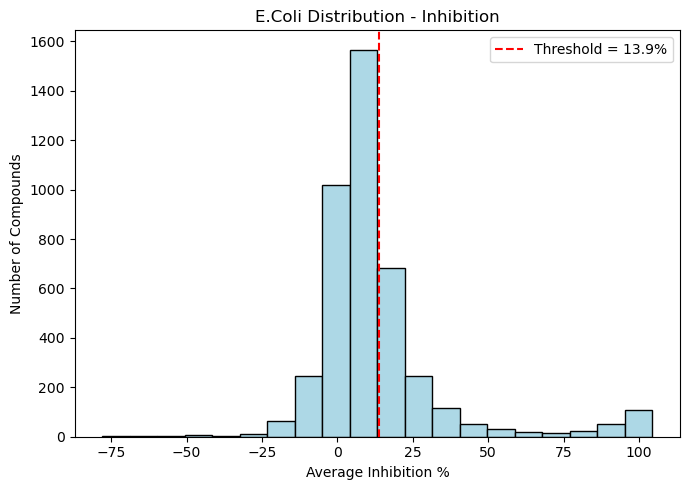

In [18]:
threshold = master_df['INHIB_AVE'].quantile(0.7)

fig, ax = plt.subplots(figsize=(7,5))

ax.hist(master_df['INHIB_AVE'], bins=20, edgecolor='black', color='lightblue')

ax.axvline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold:.1f}%')

ax.set_title('E.Coli Distribution - Inhibition')
ax.set_xlabel('Average Inhibition %')
ax.set_ylabel('Number of Compounds')
ax.legend()

plt.tight_layout()
plt.show()

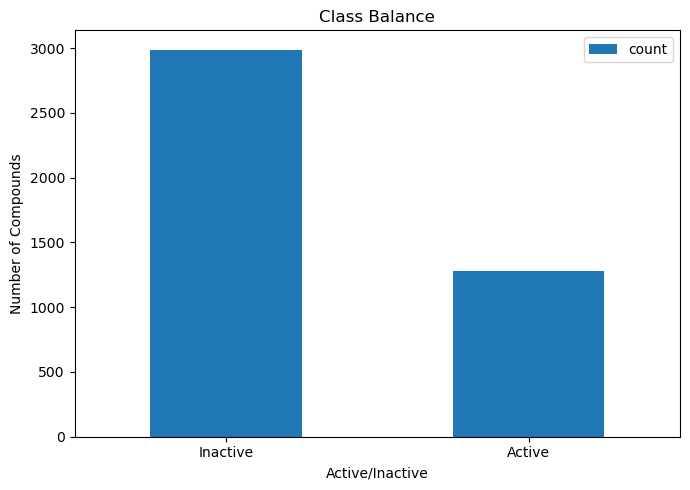

In [20]:
ydummy_train = (master_df['INHIB_AVE'] > master_df['INHIB_AVE'].quantile(0.7)).astype(int)

fig, ax = plt.subplots(figsize=(7,5))

ydummy_train.value_counts().plot(kind='bar', ax=ax)

ax.set_xticklabels(['Inactive', 'Active'], rotation=0)
ax.set_title('Class Balance')
ax.set_xlabel('Active/Inactive')
ax.set_ylabel('Number of Compounds')
ax.legend()

plt.tight_layout()
plt.show()

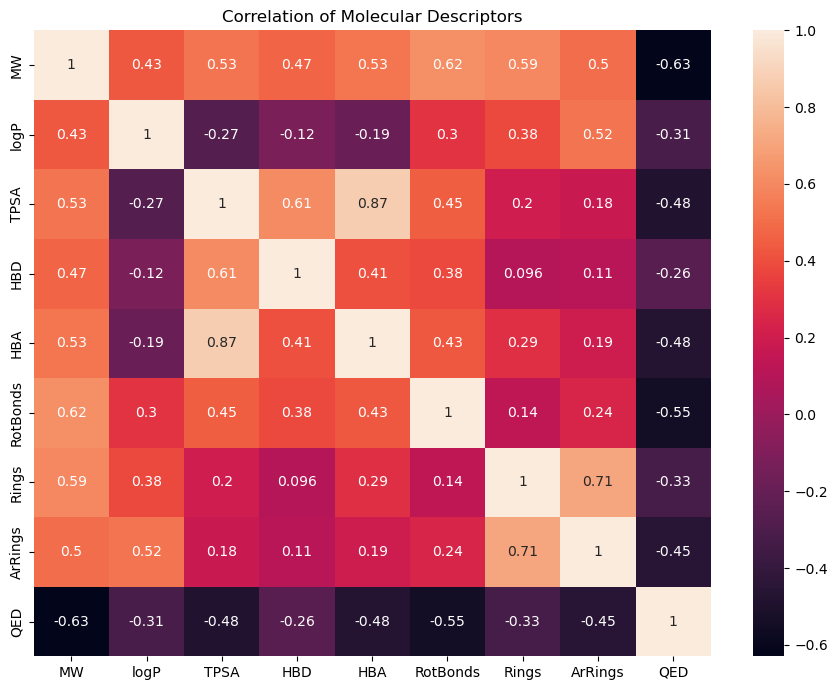

In [21]:
DESCRIPTOR_COLUMNS = ['MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED']

fig, ax = plt.subplots(figsize=(9,7))

sns.heatmap(master_df[DESCRIPTOR_COLUMNS].corr(), annot=True, ax=ax)

ax.set_title('Correlation of Molecular Descriptors')

plt.tight_layout()
plt.show()

-----------

## Clustering Visualization

/opt/miniconda3/envs/msse-python/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


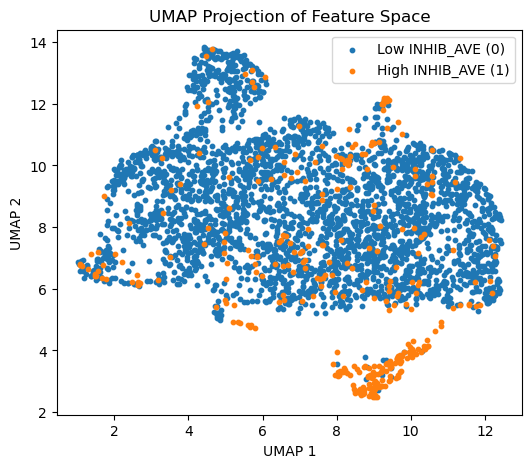

In [54]:
threshold = y_train.quantile(0.9)
y_umap = (y_train > threshold).astype(int)

umap_data = umap.UMAP(n_neighbors=30, min_dist=0.3, random_state=42).fit_transform(X_train_scaled)

plt.figure(figsize=(6, 5))

# class 0
plt.scatter(
    umap_data[y_umap == 0, 0],
    umap_data[y_umap == 0, 1],
    s=10,
    label="Low INHIB_AVE (0)"
)

# class 1
plt.scatter(
    umap_data[y_umap == 1, 0],
    umap_data[y_umap == 1, 1],
    s=10,
    label="High INHIB_AVE (1)"
)

plt.title("UMAP Projection of Feature Space")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.legend()
plt.show()

/opt/miniconda3/envs/msse-python/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


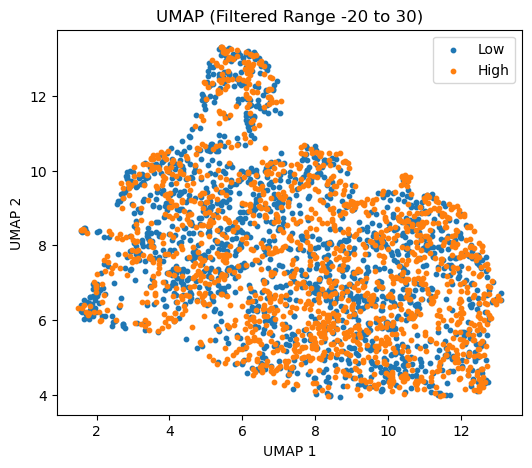

In [55]:
mask = (y_train >= -20) & (y_train <= 30)

X_umap = X_train_scaled.loc[mask].copy()
y_umap = y_train.loc[mask].copy()

umap_data = umap.UMAP(
    n_neighbors=30,
    min_dist=0.3,
    random_state=42
).fit_transform(X_umap)

labels = (y_umap > y_umap.median()).astype(int)

plt.figure(figsize=(6, 5))

plt.scatter(
    umap_data[labels == 0, 0],
    umap_data[labels == 0, 1],
    s=10,
    label="Low"
)

plt.scatter(
    umap_data[labels == 1, 0],
    umap_data[labels == 1, 1],
    s=10,
    label="High"
)

plt.title("UMAP (Filtered Range -20 to 30)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.show()

---------

## K-Means Clustering with PCA

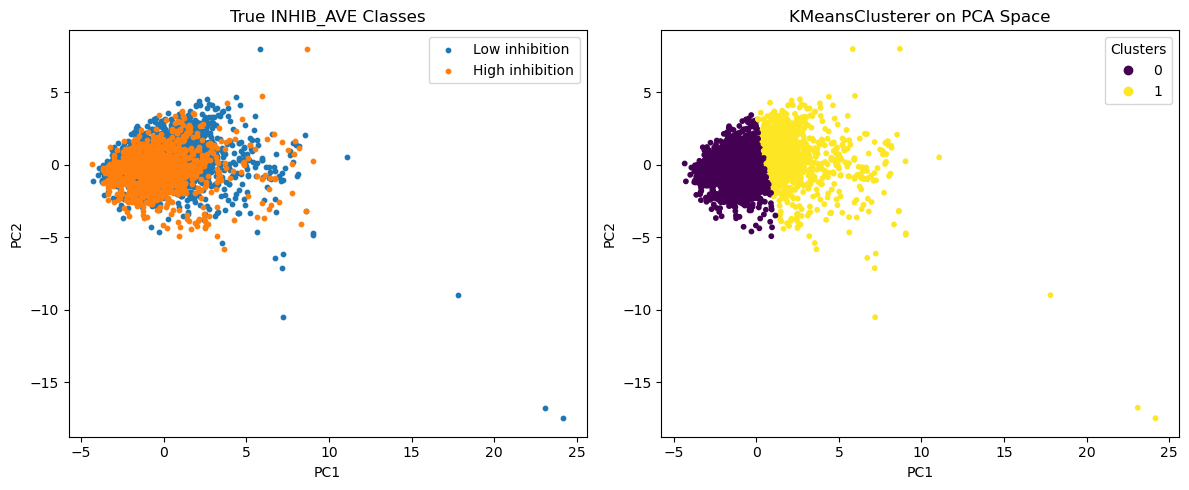

In [88]:
# PCA
X_np = X_train_scaled.to_numpy()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_np)

# binary inhibition labels
threshold = y_train.quantile(0.7)
y_train_class = (y_train > threshold).astype(int)

# KMeansClusterer (NLTK)
dist = distance_metric(type_metric.EUCLIDEAN)

km_model = KMeansClusterer(
    2,
    distance=dist,
    repeats=25,
    avoid_empty_clusters=True
)

kmeans_labels = km_model.cluster(X_pca, assign_clusters=True)

# figure
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# --- LEFT: true classes ---
axes[0].scatter(
    X_pca[y_train_class == 0, 0],
    X_pca[y_train_class == 0, 1],
    s=10,
    label="Low inhibition"
)

axes[0].scatter(
    X_pca[y_train_class == 1, 0],
    X_pca[y_train_class == 1, 1],
    s=10,
    label="High inhibition"
)

axes[0].set_title("True INHIB_AVE Classes")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()

# --- RIGHT: KMeansClusterer clusters ---
scatter = axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap='viridis',
    s=10
)

axes[1].set_title("KMeansClusterer on PCA Space")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

axes[1].legend(*scatter.legend_elements(), title="Clusters")

plt.tight_layout()
plt.show()

In [89]:
score = silhouette_score(X_pca, kmeans_labels)

print("Silhouette Score (KMeansClusterer on PCA):", score)

Silhouette Score (KMeansClusterer on PCA): 0.41050680867867784


----------------------------
## Gaussian Mixture Model and UMAP

A Gaussian Mixture Model (GMM) was applied to the distribution of INHIB_AVE to identify potential latent subpopulations in antibacterial activity. The left panel shows the fitted mixture model overlaid on the empirical distribution, where two Gaussian components capture low and high inhibition groups, and a data-driven cutoff is defined at the midpoint between component means. The right panel shows the corresponding cluster assignments for each observation, illustrating how samples are probabilistically separated into two biologically meaningful groups. This approach provides a more interpretable and data-driven alternative to an arbitrary median split for defining inhibition classes.

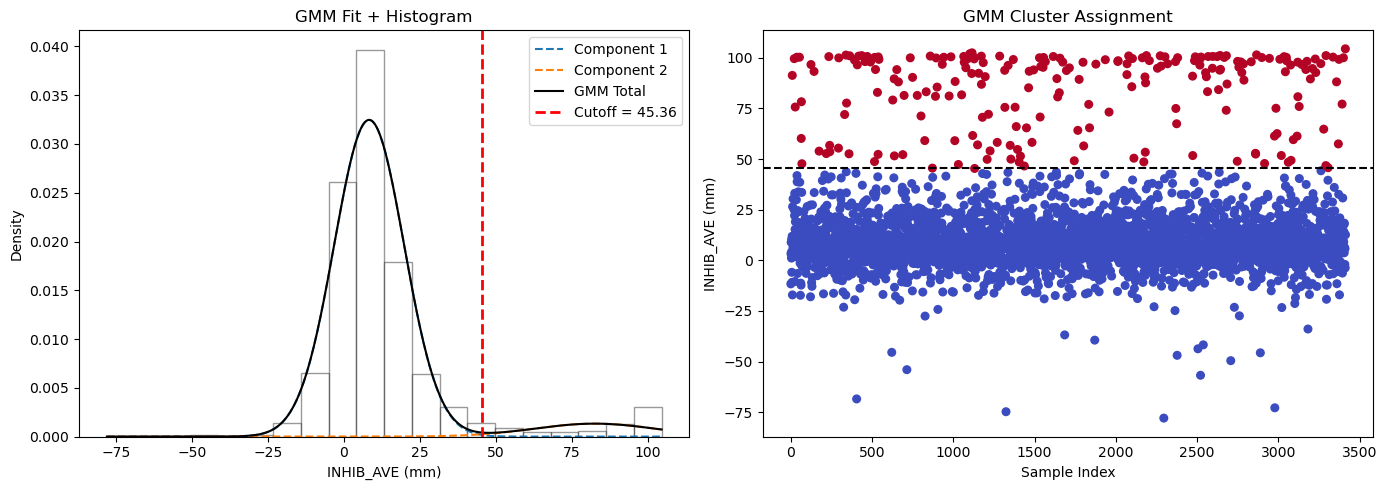

In [4]:
data = y_train.values.reshape(-1, 1)

# Fit GMM
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(data)

# Cutoff
means = gmm.means_.flatten()
threshold = np.mean(means)

# Smooth density curve
x = np.linspace(data.min(), data.max(), 500).reshape(-1, 1)
logprob = gmm.score_samples(x)
pdf = np.exp(logprob)

responsibilities = gmm.predict_proba(x)
pdf_individual = responsibilities * pdf[:, np.newaxis]

# Cluster labels for each sample
labels = gmm.predict(data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + GMM + cutoff
axes[0].hist(data, bins=20, density=True, alpha=0.4,
             color='white', edgecolor='black')

axes[0].plot(x, pdf_individual[:, 0], '--', label='Component 1')
axes[0].plot(x, pdf_individual[:, 1], '--', label='Component 2')
axes[0].plot(x, pdf, 'k-', label='GMM Total')

axes[0].axvline(threshold, color='red', linestyle='--',
                linewidth=2, label=f'Cutoff = {threshold:.2f}')

axes[0].set_title("GMM Fit + Histogram")
axes[0].set_xlabel("INHIB_AVE (mm)")
axes[0].set_ylabel("Density")
axes[0].legend()


# GMM clustering view

axes[1].scatter(range(len(data)), data, c=labels, cmap='coolwarm', s=30)

axes[1].axhline(threshold, color='black', linestyle='--')

axes[1].set_title("GMM Cluster Assignment")
axes[1].set_xlabel("Sample Index")
axes[1].set_ylabel("INHIB_AVE (mm)")

plt.tight_layout()
plt.show()

In [5]:
print("Means:", gmm.means_.flatten())
print("Variances:", gmm.covariances_.flatten())
print("Weights:", gmm.weights_.flatten())

Means: [ 8.26417649 82.45751512]
Variances: [131.52208195 401.0361858 ]
Weights: [0.9333682 0.0666318]


 ## GMM–UMAP plot

To further investigate whether the bimodal structure identified in the target variable (INHIB_AVE) is reflected in the feature space, a Gaussian Mixture Model (GMM) was fitted to INHIB_AVE to identify potential latent subpopulations. The resulting cluster assignments were then projected onto a UMAP embedding of the scaled feature set. This allows us to assess whether the distribution-based clusters correspond to any separable structure in the high-dimensional feature space.

/opt/miniconda3/envs/msse-python/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


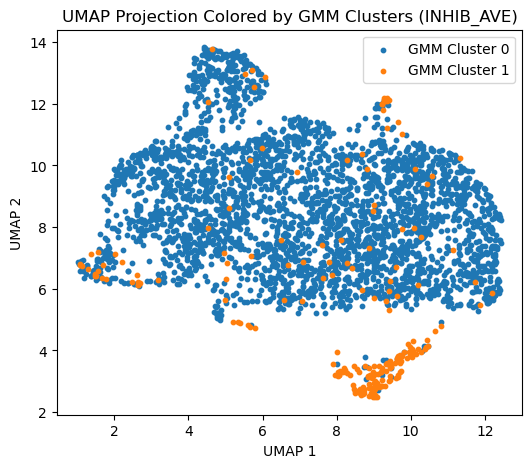

In [59]:
# UMAP on feature space
umap_data = umap.UMAP(
    n_neighbors=30,
    min_dist=0.3,
    random_state=42
).fit_transform(X_train_scaled)

# GMM labels (from y_train)
labels = gmm.predict(y_train.values.reshape(-1, 1))

plt.figure(figsize=(6, 5))

plt.scatter(
    umap_data[labels == 0, 0],
    umap_data[labels == 0, 1],
    s=10,
    label="GMM Cluster 0"
)

plt.scatter(
    umap_data[labels == 1, 0],
    umap_data[labels == 1, 1],
    s=10,
    label="GMM Cluster 1"
)

plt.title("UMAP Projection Colored by GMM Clusters (INHIB_AVE)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.show()

The Gaussian Mixture Model does not support a biologically meaningful bimodal structure in INHIB_AVE. One dominant distribution accounts for the majority of observations, while a second small component corresponds to extreme high-value outliers. Therefore, a data-driven threshold based on distribution quantiles is more appropriate than mixture-based clustering. A 70th percentile cutoff was selected to define high antibacterial activity, ensuring a balanced yet biologically meaningful classification of the strongest-performing compounds. This choice avoids sensitivity to extreme outliers observed in the distribution and provides sufficient class representation for stable model estimation.

---------------
## GMM with PCA

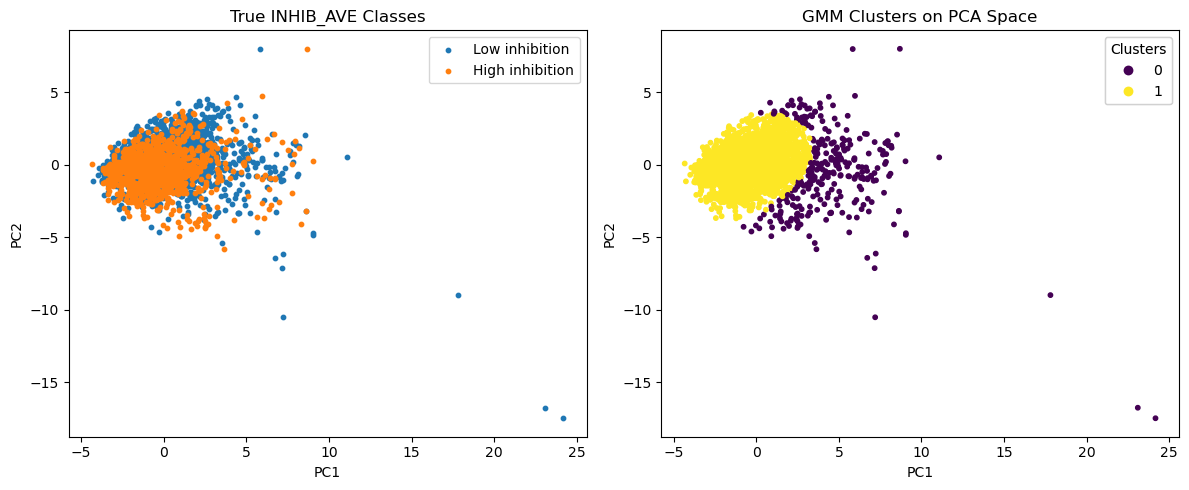

In [84]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

# binary labels
threshold = y_train.quantile(0.7)
y_train_class = (y_train > threshold).astype(int)

# GMM
gmm = GaussianMixture(n_components=2, random_state=42)
gmm_labels = gmm.fit_predict(X_pca)

# figure
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# --- LEFT: true high/low inhibition ---
axes[0].scatter(
    X_pca[y_train_class == 0, 0],
    X_pca[y_train_class == 0, 1],
    s=10,
    label="Low inhibition"
)

axes[0].scatter(
    X_pca[y_train_class == 1, 0],
    X_pca[y_train_class == 1, 1],
    s=10,
    label="High inhibition"
)

axes[0].set_title("True INHIB_AVE Classes")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()

# --- RIGHT: GMM clusters ---
scatter = axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=gmm_labels,
    cmap='viridis',
    s=10
)

axes[1].set_title("GMM Clusters on PCA Space")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

# legend for GMM
legend1 = axes[1].legend(*scatter.legend_elements(),
                         title="Clusters")
axes[1].add_artist(legend1)

plt.tight_layout()
plt.show()

In [85]:
score = silhouette_score(X_pca, labels)

print("Silhouette Score (GMM on PCA):", score)

Silhouette Score (GMM on PCA): 0.5434314988424587


------------------
## Simple Logistic Regression Model

In [6]:
threshold = y_train.quantile(0.7)

ydummy_train = (y_train > threshold).astype(int)
ydummy_test = (y_test > threshold).astype(int)

print("Threshold:", threshold)
print(ydummy_train.value_counts())

Threshold: 14.211
INHIB_AVE
0    2390
1    1024
Name: count, dtype: int64


0 = low / moderate inhibition (bottom 70%)
1 = high inhibition (top 30%)

In [7]:
X_train_glm = sm.add_constant(X_train_scaled)

glm_model = sm.GLM(ydummy_train, X_train_glm, family=sm.families.Binomial())
glm_results = glm_model.fit()

print(glm_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              INHIB_AVE   No. Observations:                 3414
Model:                            GLM   Df Residuals:                     3400
Model Family:                Binomial   Df Model:                           13
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1743.4
Date:                Sun, 03 May 2026   Deviance:                       3486.8
Time:                        23:34:16   Pearson chi2:                 3.59e+03
No. Iterations:                    19   Pseudo R-squ. (CS):             0.1815
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.9044      5.194     -0.174   

We now make prediction on test dataset

Accuracy: 0.8044496487119438
                   Feature      Coef  Odds Ratio
DMAX_AVE          DMAX_AVE  1.150453    3.159624
HBD                    HBD  0.241687    1.273396
HBA                    HBA  0.184694    1.202850
ArRings            ArRings  0.178402    1.195306
MIC_VALUE_uM  MIC_VALUE_uM  0.158987    1.172323
MW                      MW  0.135642    1.145271
INHIB_STD        INHIB_STD  0.123651    1.131621
logP                  logP  0.058950    1.060722
QED                    QED -0.039889    0.960896
TPSA                  TPSA -0.191269    0.825911
RotBonds          RotBonds -0.228881    0.795424
NASSAYS            NASSAYS -0.314491    0.730161
Rings                Rings -0.412249    0.662160


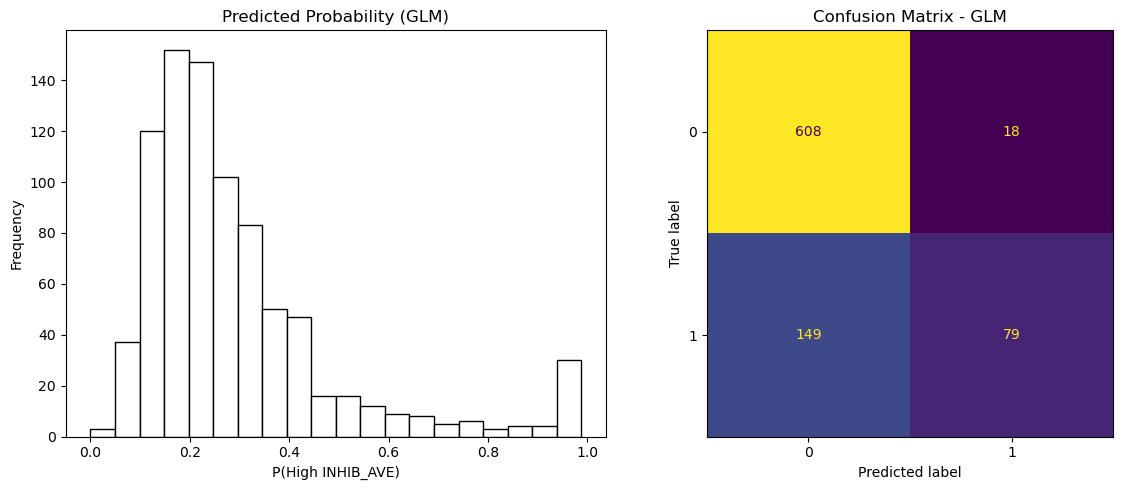

In [8]:
X_test_glm = sm.add_constant(X_test_scaled)

y_prob_log = glm_results.predict(X_test_glm)
y_pred_log = (y_prob_log > 0.5).astype(int)
print("Accuracy:", accuracy_score(ydummy_test, y_pred_log))

coefficients = pd.DataFrame({"Feature": X_train_scaled.columns, "Coef": glm_results.params[1:]})

coefficients["Odds Ratio"] = np.exp(coefficients["Coef"])

print(coefficients.sort_values("Odds Ratio", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


# Probability histogram
axes[0].hist(y_prob_log, bins=20, edgecolor='black', color='white')
axes[0].set_title("Predicted Probability (GLM)")
axes[0].set_xlabel("P(High INHIB_AVE)")
axes[0].set_ylabel("Frequency")


# Confusion matrix
cm = confusion_matrix(ydummy_test, y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[1], colorbar=False)

axes[1].set_title("Confusion Matrix - GLM")

plt.tight_layout()
plt.show()

In [9]:
from sklearn.metrics import classification_report
print(classification_report(ydummy_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.80      0.97      0.88       626
           1       0.81      0.35      0.49       228

    accuracy                           0.80       854
   macro avg       0.81      0.66      0.68       854
weighted avg       0.81      0.80      0.77       854



While the GLM achieved an overall accuracy of 0.80, performance was strongly imbalanced across classes. The model showed high recall for low-inhibition compounds (0.97), but substantially lower recall for high-inhibition compounds (0.35), indicating a conservative prediction bias. This suggests that the model prioritizes specificity over sensitivity, leading to a significant number of false negatives among biologically active compounds. As a result, accuracy alone is not sufficient to evaluate model performance in this context, and metrics such as a confusion matrix and recall provide a more informative assessment.

-------------
## Logistic Regression with Feature Selection

Several predictors exhibited high p-values, suggesting redundancy and multicollinearity among molecular descriptors. While PCA could reduce dimensionality, it would compromise interpretability. Therefore, feature selection or more flexible nonlinear models may be more appropriate for capturing the structure–activity relationships present in the dataset.

In [10]:
selected_features = [
    "DMAX_AVE",
    "HBD",
    "HBA",
    "ArRings",
    "MIC_VALUE_uM",
    "INHIB_STD",
    "RotBonds",
    "Rings"
]

X_train_sel = sm.add_constant(X_train_scaled[selected_features])
X_test_sel = sm.add_constant(X_test_scaled[selected_features])

glm_sel = sm.GLM(ydummy_train, X_train_sel, family=sm.families.Binomial())
glm_sel_results = glm_sel.fit()

print(glm_sel_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              INHIB_AVE   No. Observations:                 3414
Model:                            GLM   Df Residuals:                     3405
Model Family:                Binomial   Df Model:                            8
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1748.2
Date:                Sun, 03 May 2026   Deviance:                       3496.4
Time:                        23:34:44   Pearson chi2:                 3.54e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1792
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.8931      0.043    -20.993   

Accuracy: 0.8009367681498829


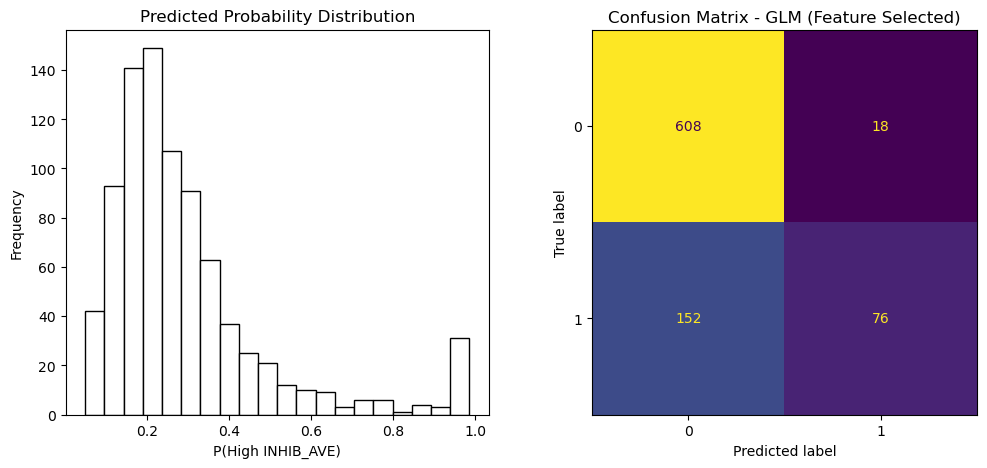


Report:
               precision    recall  f1-score   support

           0       0.80      0.97      0.88       626
           1       0.81      0.33      0.47       228

    accuracy                           0.80       854
   macro avg       0.80      0.65      0.67       854
weighted avg       0.80      0.80      0.77       854



In [11]:
y_prob_sel = glm_sel_results.predict(X_test_sel)
y_pred_sel = (y_prob_sel > 0.5).astype(int)

print("Accuracy:", accuracy_score(ydummy_test, y_pred_sel))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm = confusion_matrix(ydummy_test, y_pred_sel)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[1], colorbar=False)

axes[1].set_title("Confusion Matrix - GLM (Feature Selected)")

axes[0].hist(y_prob_sel, bins=20, edgecolor='black', color='white')
axes[0].set_title("Predicted Probability Distribution")
axes[0].set_xlabel("P(High INHIB_AVE)")
axes[0].set_ylabel("Frequency")

plt.show()

print("\nReport:\n", classification_report(ydummy_test, y_pred_sel))

The limitations observed in the GLM suggest that the relationship between molecular descriptors and antibacterial activity is nonlinear. This motivates the use of nonlinear classifiers such as Support Vector Machines and tree-based ensemble methods, which can better capture complex decision boundaries in the feature space.

-------------------------

## Simple Linear Regression

In [12]:
# build training dataframe
lin_df = X_train_scaled.copy()
lin_df["INHIB_AVE"] = y_train

# formula
equation = "INHIB_AVE ~ " + " + ".join(X_train_scaled.columns)

# fit model
lin_model = ols(equation, data=lin_df).fit()

# summary
print(lin_model.summary())

                            OLS Regression Results                            
Dep. Variable:              INHIB_AVE   R-squared:                       0.540
Model:                            OLS   Adj. R-squared:                  0.538
Method:                 Least Squares   F-statistic:                     306.8
Date:                Sun, 03 May 2026   Prob (F-statistic):               0.00
Time:                        23:42:15   Log-Likelihood:                -14100.
No. Observations:                3414   AIC:                         2.823e+04
Df Residuals:                    3400   BIC:                         2.831e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       13.2078      0.258     51.193   

In [14]:
# build test dataframe
lin_test_df = X_test_scaled.copy()

# predict
y_pred_lin = lin_model.predict(lin_test_df)

r2 = r2_score(y_test, y_pred_lin)
mse = mean_squared_error(y_test, y_pred_lin)
mae = mean_absolute_error(y_test, y_pred_lin)
rmse = np.sqrt(mse)

print("R2:", r2)
print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)

R2: 0.4665522537903286
MSE: 222.34644808485203
MAE: 10.123529834573203
RMSE: 14.911285929954264


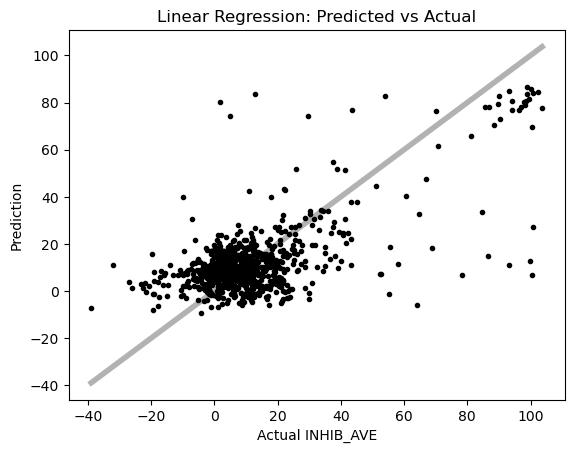

Mean Absolute Deviation: 10.123529834573203


In [15]:
higher = max(y_pred_lin.max(), y_test.max())
lower = min(y_pred_lin.min(), y_test.min())
plt.plot([lower, higher], [lower, higher],
         color='black', alpha=0.3, linewidth=4)

# scatter plot
plt.scatter(y_test, y_pred_lin, marker='.', color='black')

plt.ylabel('Prediction')
plt.xlabel('Actual INHIB_AVE')
plt.title('Linear Regression: Predicted vs Actual')

plt.show()

# mean absolute deviation
mean_dev = np.mean(np.abs(y_test - y_pred_lin))
print("Mean Absolute Deviation:", mean_dev)

------------------

## Simple Linear Regression with Feature Selection

                            OLS Regression Results                            
Dep. Variable:              INHIB_AVE   R-squared:                       0.538
Model:                            OLS   Adj. R-squared:                  0.538
Method:                 Least Squares   F-statistic:                     1326.
Date:                Sun, 03 May 2026   Prob (F-statistic):               0.00
Time:                        23:50:34   Log-Likelihood:                -14105.
No. Observations:                3414   AIC:                         2.822e+04
Df Residuals:                    3410   BIC:                         2.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.2078      0.258     51.191      0.0

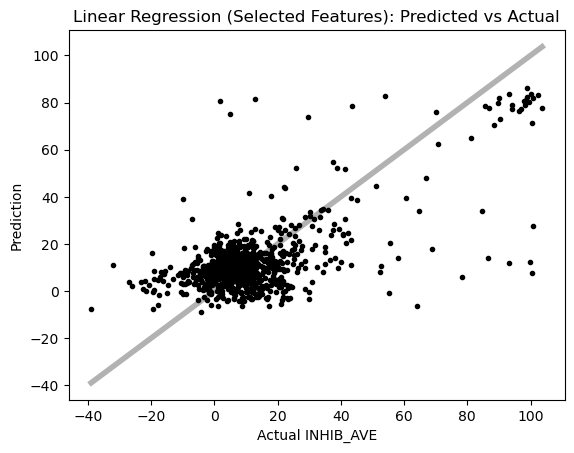

Mean Absolute Deviation: 10.17643601586475


In [16]:
# 1. Build training dataframe

selected_features = ["DMAX_AVE", "MW", "Rings"]

lin_df = X_train_scaled.copy()
lin_df["INHIB_AVE"] = y_train

# build formula
equation = "INHIB_AVE ~ " + " + ".join(selected_features)

# fit model
lin_model_fs = ols(equation, data=lin_df).fit()

print(lin_model_fs.summary())



# 2. Test predictions
lin_test_df = X_test_scaled.copy()

y_pred_lin_fs = lin_model_fs.predict(lin_test_df)

# 3. Metrics

r2 = r2_score(y_test, y_pred_lin_fs)
mse = mean_squared_error(y_test, y_pred_lin_fs)
mae = mean_absolute_error(y_test, y_pred_lin_fs)
rmse = np.sqrt(mse)

print("\n--- Feature Selected Model ---")
print("R2:", r2)
print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)



# 4. Regression Plot

higher = max(y_pred_lin_fs.max(), y_test.max())
lower = min(y_pred_lin_fs.min(), y_test.min())

plt.plot([lower, higher], [lower, higher],
         color='black', alpha=0.3, linewidth=4)

plt.scatter(y_test, y_pred_lin_fs, marker='.', color='black')

plt.ylabel('Prediction')
plt.xlabel('Actual INHIB_AVE')
plt.title('Linear Regression (Selected Features): Predicted vs Actual')

plt.show()

# 5. Mean absolute deviation

mean_dev = np.mean(np.abs(y_test - y_pred_lin_fs))
print("Mean Absolute Deviation:", mean_dev)

------------------

## Error Weighted and Selected X_Train Windown for Simple Linear Regression

In [17]:
mask_train = (y_train >= -20) & (y_train <= 30)
mask_test = (y_test >= -20) & (y_test <= 30)

X_train_f = X_train_scaled.loc[mask_train].copy()
y_train_f = y_train.loc[mask_train].copy()

X_test_f = X_test_scaled.loc[mask_test].copy()
y_test_f = y_test.loc[mask_test].copy()

In [37]:
# remove INHIB_STD and NASSAYSfrom feature
X_train_w = X_train_f.drop(columns=["INHIB_STD", "NASSAYS"])
X_test_w  = X_test_f.drop(columns=["INHIB_STD", "NASSAYS"])

In [40]:
# Fit WLS

alphas = [0.5, 1.0, 1.5, 2.0]
epsilons = [1e-3, 1e-2, 1e-1, 1]

results = []

X_train_w_const = sm.add_constant(X_train_w)
X_test_w_const = sm.add_constant(X_test_w)

for alpha in alphas:
    for eps in epsilons:
       # error weighing
       w = 1 / ((X_train_f["INHIB_STD"] + eps) ** alpha)

       # stabilize
       w = np.nan_to_num(w, nan=1.0, posinf=50, neginf=1.0)
       w = np.clip(w, 0, 50)
       w = w / np.mean(w)

       weights = w

       model = sm.WLS(y_train_f, X_train_w_const, weights=weights).fit()

       y_pred = model.predict(X_test_w_const)

       r2 = r2_score(y_test_f, y_pred)
       rmse = np.sqrt(mean_squared_error(y_test_f, y_pred))

       results.append((alpha, eps, r2, rmse))

scored_results = []

for r in results:
    alpha, eps, r2, rmse = r

    score = r2 - 0.01 * rmse  # balance fit + error

    scored_results.append((alpha, eps, r2, rmse, score))

scored_results = sorted(scored_results, key=lambda x: x[4], reverse=True)

for r in scored_results[:5]:
    print("alpha:", r[0],
          "eps:", r[1],
          "R2:", r[2],
          "RMSE:", r[3],
          "Score:", r[4])

alpha: 0.5 eps: 1 R2: 0.0697131778780764 RMSE: 8.71354941559444 Score: -0.017422316277867986
alpha: 1.0 eps: 1 R2: 0.06655687565590274 RMSE: 8.728318681552626 Score: -0.02072631115962352
alpha: 0.5 eps: 0.1 R2: 0.06635477709170934 RMSE: 8.729263508911894 Score: -0.020937857997409604
alpha: 2.0 eps: 0.1 R2: 0.06562040589104479 RMSE: 8.732695893875743 Score: -0.021706553047712643
alpha: 2.0 eps: 0.01 R2: 0.06474644583102407 RMSE: 8.736778947315619 Score: -0.022621343642132127


Best alpha: 0.5
Best eps: 1
Best RMSE: 8.71354941559444
Best R2: 0.0697131778780764

Final Model Performance:
R2: 0.0697131778780764
RMSE: 8.71354941559444


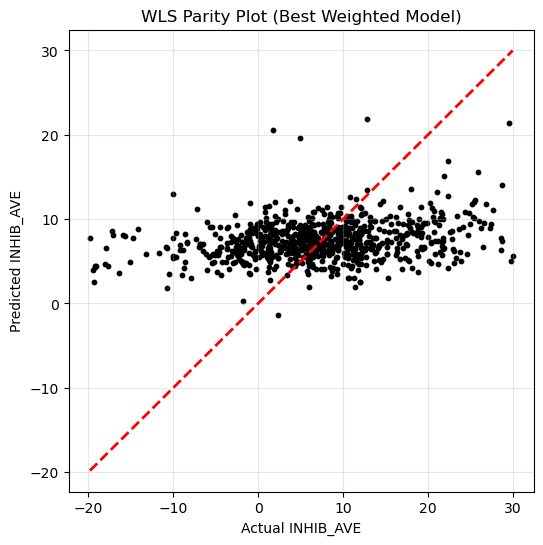

In [41]:
best_alpha, best_eps, best_r2, best_rmse = sorted(results, key=lambda x: x[3])[0]

print("Best alpha:", best_alpha)
print("Best eps:", best_eps)
print("Best RMSE:", best_rmse)
print("Best R2:", best_r2)

w = 1 / ((X_train_f["INHIB_STD"] + best_eps) ** best_alpha)

w = np.nan_to_num(w, nan=1.0, posinf=50, neginf=1.0)
w = w / np.mean(w)

model = sm.WLS(
    y_train_f,
    sm.add_constant(X_train_w),
    weights=w
).fit()

y_pred = model.predict(sm.add_constant(X_test_w))

r2 = r2_score(y_test_f, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_f, y_pred))

print("\nFinal Model Performance:")
print("R2:", r2)
print("RMSE:", rmse)

plt.figure(figsize=(6, 6))

plt.scatter(y_test_f, y_pred, s=10, color='black')

min_val = min(y_test_f.min(), y_pred.min())
max_val = max(y_test_f.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linestyle='--', linewidth=2)

plt.xlabel("Actual INHIB_AVE")
plt.ylabel("Predicted INHIB_AVE")
plt.title("WLS Parity Plot (Best Weighted Model)")

plt.grid(True, alpha=0.3)
plt.show()